# Project data exploration - looking at relplot and scatter plots
Using a dataset that your group is consider using for the term project, let's do some data exploring of the different features in your dataset and their relationships

Group name: Team Ram Price  
Created by Anthony Kieu (017517565), Anson Lau (016934905)  
Last updated: 03/07/2026
Briefly describe your dataset

Import your data. If you want to mount your Google drive you can use `from google.colab import drive` and `drive.mount('/content/drive')`

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import glob
import os
import re
%matplotlib inline

In [ ]:
!git clone https://github.com/HardwareDealsCo/ram-deals.git
#found this dataset on github and so we cloned it to this project file.

Cloning into 'ram-deals'...
remote: Enumerating objects: 957, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 957 (delta 17), reused 0 (delta 0), pack-reused 927 (from 1)
Receiving objects: 100% (957/957), 11.51 MiB | 24.39 MiB/s, done.
Resolving deltas: 100% (626/626), done.


In [ ]:
# Data is separated into different json files in the github, we want to combine to make one large dataset
files = glob.glob("ram-deals/historical-ram-deals-data/*.json")
#there are multiple json files in the original github dataset because they updated prices for each day

df_list = []

for fname in files:
    base = os.path.basename(fname)

    #I'm find the data pattern from the file name
    match = re.search(r"\d{4}-\d{2}-\d{2}", base)

    if match:
        date = pd.to_datetime(match.group())
    else:
        continue

    with open(fname) as f:
        data = json.load(f)

    temp_df = pd.DataFrame(data)

    # Add datetime column
    temp_df["date"] = date

    df_list.append(temp_df)

ram_data = pd.concat(df_list, ignore_index=True)

In [ ]:
#too many values, we'll start with 20k random values just for the sake of it
ram_data = ram_data.sample(n=20000, random_state = 50)

### Q1: Show the number of missing data in each column of the dataframe

In [ ]:
# Your code here . . .
print(ram_data.isnull().sum())
print(ram_data.info()) #just to confirm

#this dataset seems to be pretty good
#the columns 'title', 'brand', 'price', 'capacity_gb', 'speed', 'form_factor', 'condition', 'link', 'source', and 'date' aren't missing any data.
#'$/gb' column has 1 null values
# 'itemGroupType' seems to be all nulls, we will clean this up and get rid of this column because it seems to be useless


title                0
brand                0
price                0
$/gb                 0
currency             0
capacity_gb          0
speed                0
form_factor          0
condition            0
link                 0
source               0
itemGroupType    20000
date                 0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 200881 to 133535
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   title          20000 non-null  object        
 1   brand          20000 non-null  object        
 2   price          20000 non-null  object        
 3   $/gb           20000 non-null  float64       
 4   currency       20000 non-null  object        
 5   capacity_gb    20000 non-null  int64         
 6   speed          20000 non-null  object        
 7   form_factor    20000 non-null  object        
 8   condition      20000 non-null  object        
 9   link        

In [ ]:
#seems to be useless, so we'll drop
ram_data.drop('itemGroupType', axis=1)

,title,brand,price,$/gb,currency,capacity_gb,speed,form_factor,condition,link,source,date
200881,Corsair CMSX96GX5M2A5600C48 Vengeance DDR5 LAP...,Corsair,497.99,5.187396,USD,96,DDR5,Laptop,New,https://www.ebay.com/itm/197890232641?campid=5...,Ebay,2025-11-24
144963,Patriot Viper Venom 32GB (2 x 16GB) 288-Pin PC...,Patriot,89.99,2.812187,USD,32,DDR5,Desktop,New,https://www.ebay.com/itm/387737947523?campid=5...,Ebay,2025-09-23
406510,2x Hynix 4GB DDR3 PC3L-12800S 1600MHz 1Rx8 Lap...,SK Hynix,10.00,2.500000,USD,4,DDR3,Laptop,Used,https://www.ebay.com/itm/365464524096?campid=5...,Ebay,2025-12-14
399979,Kingston 32GB DDR4 3200MHz 260-pin SoDIMM Memo...,Kingston,235.10,7.346875,USD,32,DDR4,Laptop,New,https://www.ebay.com/itm/389475005189?campid=5...,Ebay,2026-01-10
268246,2GB DDR3 PC3-10600 1333MHz SODIMM (HP 577605-0...,HP,14.43,7.215000,USD,2,DDR3,Laptop,New,https://www.ebay.com/itm/224440225677?campid=5...,Ebay,2025-10-13
...,...,...,...,...,...,...,...,...,...,...,...,...
374670,RAM Samsung 32GB 2Rx8 DDR4-3200 M378A4G43BB2-C...,Samsung,195.00,6.093750,USD,32,DDR4-3200,Server,Open box,https://www.ebay.com/itm/357964896013?campid=5...,Ebay,2025-11-30
327691,16GB RAM Lenovo ThinkPad L14 Gen 2 20X6 DDR4 L...,Lenovo,114.95,7.184375,USD,16,DDR4,Laptop,New,https://www.ebay.com/itm/375349245943?campid=5...,Ebay,2025-12-03
252870,G.SKILL Trident Z5 RGB 32GB (2 x 16GB) DDR5-64...,G.Skill,365.00,11.406250,USD,32,DDR5-6400,Desktop,New,https://www.ebay.com/itm/136823291056?campid=5...,Ebay,2025-12-17
156142,SAMSUNG 16GB 2x8GB DDR3L 1600MHz PC3L-12800S S...,Samsung,26.00,1.625000,USD,16,1600MHz,Laptop,Open box,https://www.ebay.com/itm/395367108089?campid=5...,Ebay,2025-10-21


### Q2: Show the data type for each column of the dataframe

In [ ]:
# Your code here . . .
ram_data.dtypes

,0
title,object
brand,object
price,object
$/gb,float64
currency,object
capacity_gb,int64
speed,object
form_factor,object
condition,object
link,object


In [ ]:
#turning it into numerical number to plot
ram_data['price'] = pd.to_numeric(ram_data['price'], errors='coerce')
ram_data.head()
ram_data.dtypes

,0
title,object
brand,object
price,float64
$/gb,float64
currency,object
capacity_gb,int64
speed,object
form_factor,object
condition,object
link,object


### Q3: Create a pair plot to show pairwise relationship in this dataset.
Draw the pairwise polynomial regression lines in a different color than the data points. Use a light color for the data points to deemphasizing the points to make the regression line stand out. Include a meaningful title to the plot.

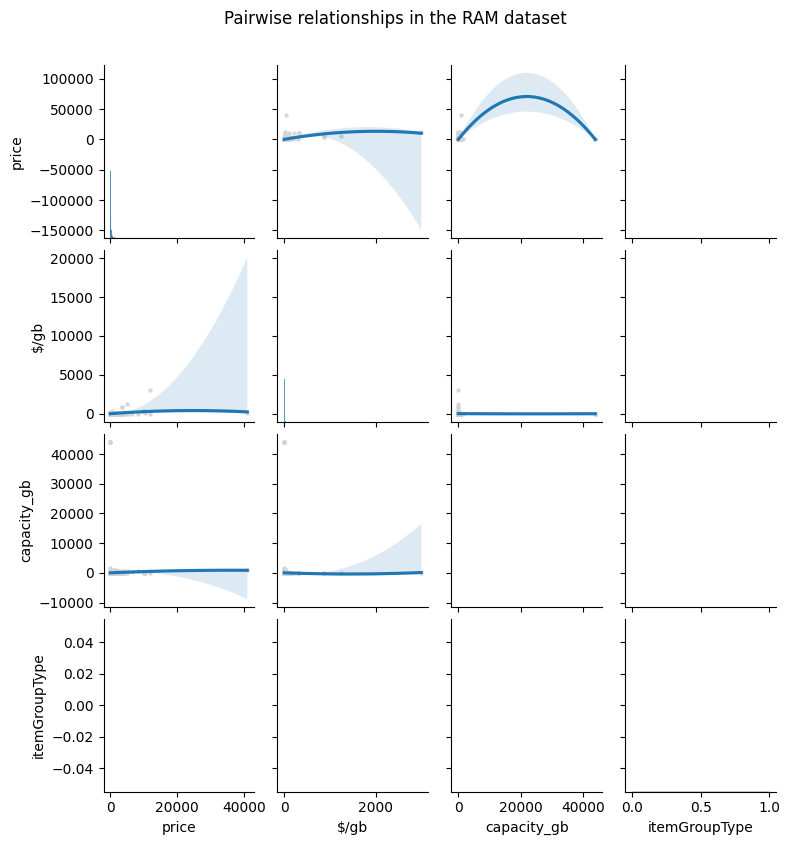

In [ ]:
# Your code here . . .
pairs = sns.pairplot(
    data = ram_data.drop(['title', 'brand', 'condition', 'link', 'source'], axis=1),
    kind = 'reg',
    plot_kws= {"scatter_kws":{"color":'lightgrey', "s":5}, "order":2},
    height = 2
);

pairs.fig.suptitle("Pairwise relationships in the RAM dataset", y = 1.05);

### Q4: Plot a regression line and confidence interval
Select two of the features from your dataset and create a lmplot that shows the linear regression between them. Filter your data as you see fit. Include a meaningful title for the plot.

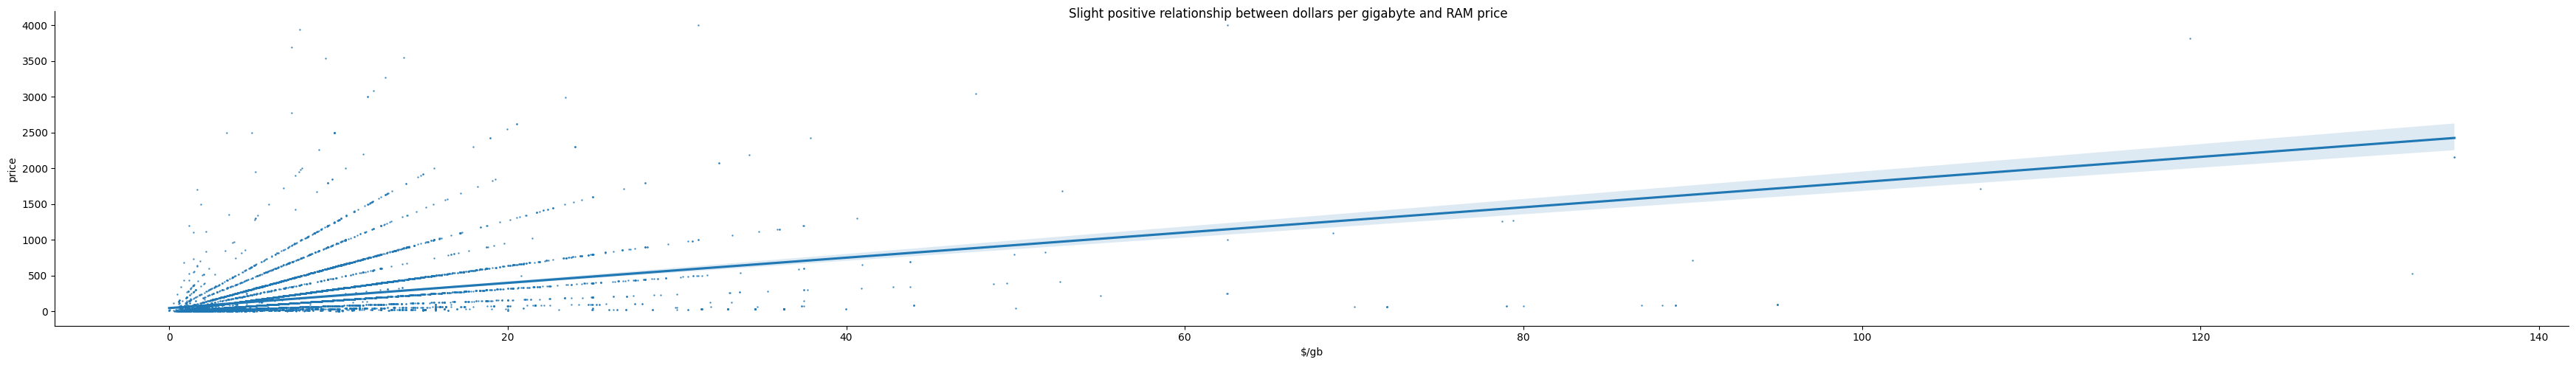

In [ ]:
# Your code here . . .
q4 = sns.lmplot(
    data = ram_data[(ram_data.price < 4000) & (ram_data['$/gb'] < 150)],
    x = '$/gb',
    y = 'price',
    order = 1,
    ci = 90,
    scatter_kws = {'s':2},
    markers = '.',
    aspect = 7
)

q4.fig.suptitle("Slight positive relationship between dollars per gigabyte and RAM price");

### Q5. Create a relplot that shows multiple features in a single plot.
Select two features from your dataset and plot a scatter plot. Select two additional features you want to highlight in your data points using `hue` and `size`. Include a meaningful title to the plot.

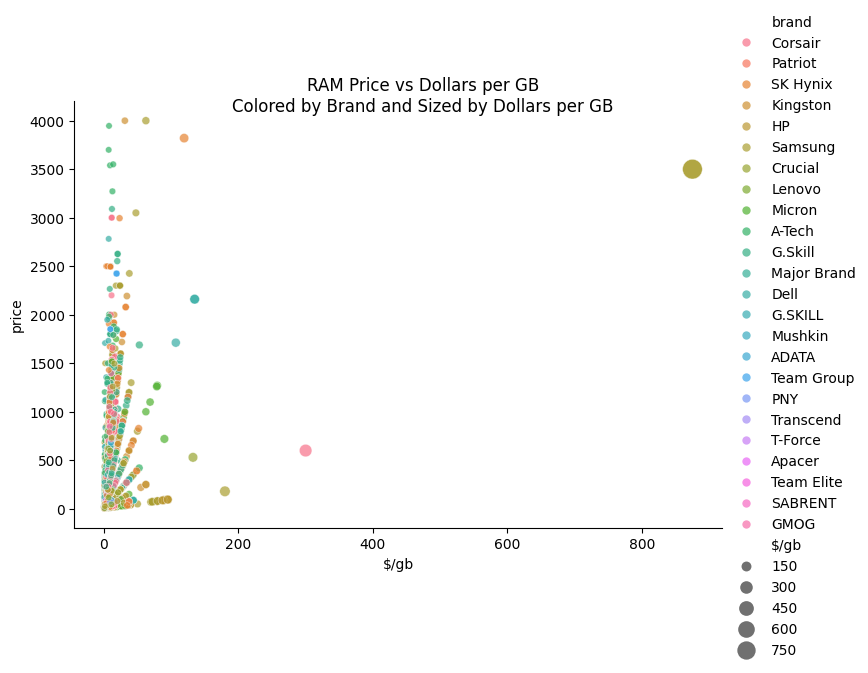

In [ ]:
# Your code here . . .
q5 = sns.relplot(
    data = ram_data[(ram_data['price'] < 4000)],
    x = '$/gb',
    y = 'price',
    hue = 'brand',
    size = '$/gb',
    sizes = (20, 200),
    alpha = 0.7,
    aspect = 1.5
)

q5.fig.suptitle(
    "RAM Price vs Dollars per GB\nColored by Brand and Sized by Dollars per GB",
    y=1.02
)

plt.show()

### Q6: Create a plot with small multiples plots
Select two features from your dataset and show the relationship between the features with an additional feature as the single category. Organize the multiple plots to have 3 plots per row. Set the `height` of the plot to 5 and the size the of data point to 20. Include a meaningful title in the plot.

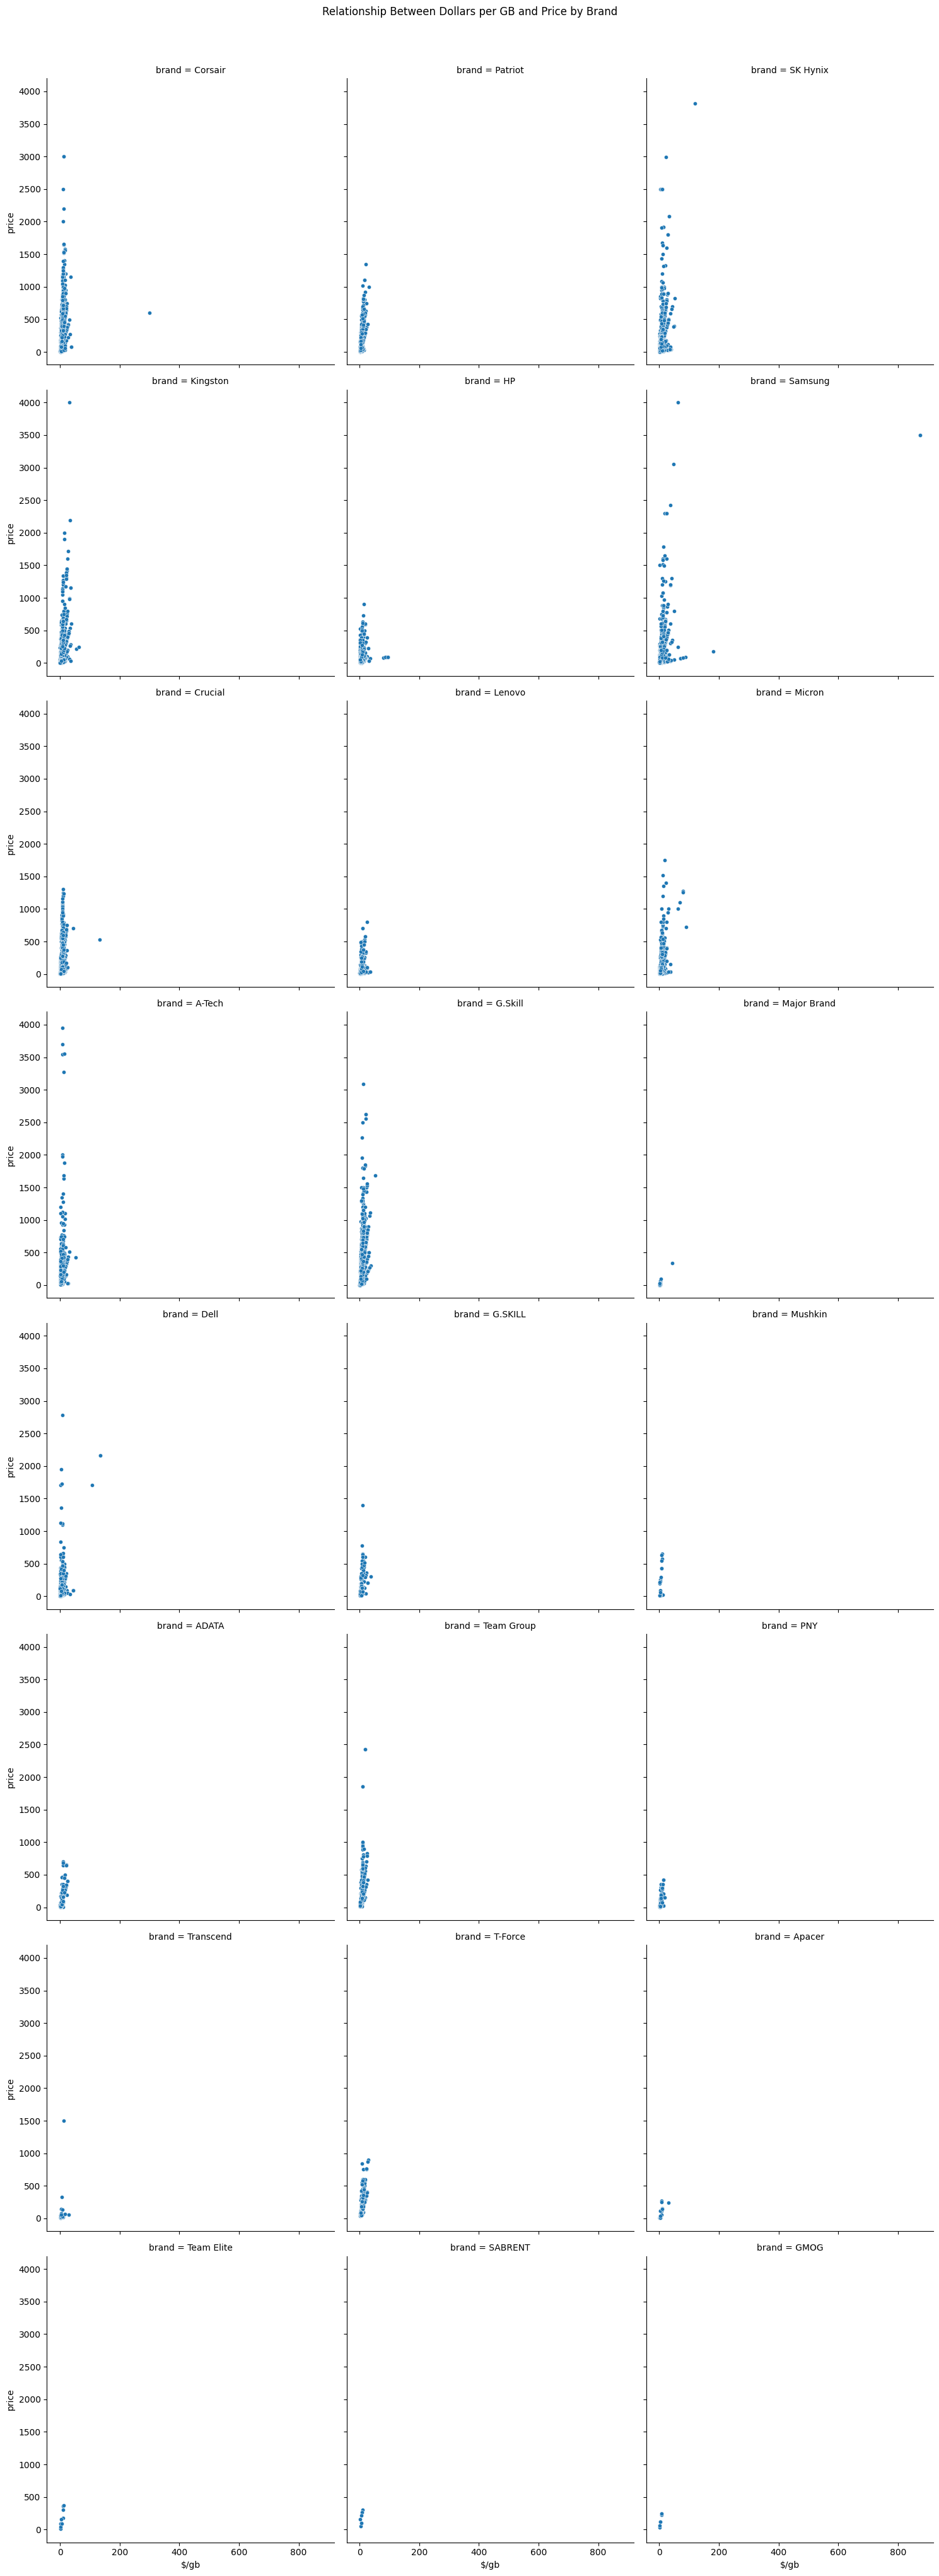

In [ ]:
q6 = sns.relplot(
    data = ram_data[ram_data['price'] < 4000],
    x = '$/gb',
    y = 'price',
    col = 'brand',
    col_wrap = 3,
    height = 5,
    s = 20
)

q6.fig.suptitle(
    "Relationship Between Dollars per GB and Price by Brand",
    y=1.02
)

plt.show()